# Imports

In [1]:
import pandas as pd
import numpy as np
import os
import regex as re
import string
import json
import soundfile as sf
import IPython.display as ipd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from pydub import AudioSegment
from tqdm.auto import tqdm
tqdm.pandas()
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from itertools import permutations, product, zip_longest, chain
import torch
import torch.nn.functional as F
from transformers import pipeline, Wav2Vec2ForCTC, AutoProcessor
import evaluate
from evaluate import load
from sklearn.model_selection import train_test_split
from datasets import load_dataset, Audio
from collections import Counter, defaultdict
import random

c:\Users\summe\OneDrive - George Mason University - O365 Production\Desktop\Akuzipik_ASR\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
from transformers import Wav2Vec2CTCTokenizer, Wav2Vec2FeatureExtractor, Wav2Vec2Processor, Wav2Vec2ForCTC, TrainingArguments, Trainer
from datasets import Dataset, Features, Value
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Union
# from safetensors.torch import save_file as safe_save_file
# from transformers.models.wav2vec2.modeling_wav2vec2 import WAV2VEC2_ADAPTER_SAFE_FILE

In [3]:
def clean_sentence(s):
    s = re.sub('…', ', ', s)
    s = re.sub('‐', '', s)
    s = re.sub('“', '', s)
    s = re.sub('”', '', s)
    s = s.translate(str.maketrans('', '', string.punctuation))
    s = re.sub('\s+', ' ', s)
    return s.lower().strip()

In [4]:
def get_dur(file_path):
    with sf.SoundFile(file_path) as audio_file:
        duration_seconds = audio_file.frames / audio_file.samplerate
        #print(file_path)
        return duration_seconds

In [5]:
torch.cuda.set_device(0)
device = torch.device("cuda:0")

In [6]:
torch.__version__

'2.8.0+cu128'

In [7]:
torch.cuda.is_available()

True

# Read in Transcribed Data

In [8]:
nw_df = pd.read_pickle('read_fable_df.pkl') #Read Fable
nw_df['dataset'] = 'read_fable'
nw_df['SentenceText'] = nw_df['SentenceText'].apply(clean_sentence)
read_df = pd.read_pickle('read_phrases_df.pkl') #Read Phrases
read_df['dataset'] = 'read_phrases'
read_df['SentenceText'] = read_df['SentenceText'].apply(clean_sentence)
spontaneous_df = pd.read_pickle('spontaneous_story_df.pkl') #Spontaneous Story
spontaneous_df['dataset'] = 'spontaneous_story'
spontaneous_df['SentenceText'] = spontaneous_df['SentenceText'].apply(clean_sentence)

In [9]:
all_df = pd.concat([nw_df, read_df, spontaneous_df], ignore_index=True).reset_index(drop=True)

In [10]:
nw_df.duration.sum()/60, read_df.duration.sum()/60, spontaneous_df.duration.sum()/60

(4.020109375, 26.165780208333334, 12.317954166666668)

In [11]:
all_df.duration.sum()/60

42.50384375

In [12]:
nw_df_sents = list(nw_df.SentenceText.unique())
read_df_sents = list(read_df.SentenceText.unique())
spontaneous_df_sents = list(spontaneous_df.SentenceText)
all_sents = read_df_sents + spontaneous_df_sents + nw_df_sents

In [13]:
all_df.groupby('dataset').cer.mean()

dataset
read_fable           0.031097
read_phrases         0.157859
spontaneous_story    0.200969
Name: cer, dtype: float64

# Initial Model Evaluation

In [13]:
model_id = "facebook/mms-1b-all"
processor = AutoProcessor.from_pretrained(model_id)
model = Wav2Vec2ForCTC.from_pretrained(model_id)

In [92]:
processor.tokenizer.set_target_lang("ess") # Akuzipik (St. Lawrence Island or Siberian Yupik) language code
model.load_adapter("ess")

In [93]:
model.to(device)

Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projec

In [94]:
torch.cuda.empty_cache()

In [95]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

In [96]:
trans_dict = {}
logit_dict = {}
for row in tqdm(all_df.itertuples(), total=len(all_df)):
    try:
        data, sr = sf.read(row.audio_path)
        inputs = processor(data, sampling_rate=sr, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs).logits
        logit_dict[row.audio_path] = outputs.cpu().numpy()
        ids = torch.argmax(outputs, dim=-1)[0]
        transcription = processor.decode(ids)
        trans_dict[row.audio_path] = transcription
    except Exception as e:
        print(e, row.Index)

  0%|          | 0/613 [00:00<?, ?it/s]

In [98]:
all_df['MetaTranscript'] = all_df['audio_path'].map(trans_dict)
all_df['MetaTranscript'] = all_df['MetaTranscript'].apply(clean_sentence)
all_df['MetaLogits'] = all_df['audio_path'].map(logit_dict)

In [99]:
cer_list = []
wer_list = []
for row in tqdm(all_df.itertuples(), total=len(all_df)):
    cer_list.append(cer_metric.compute(predictions=[row.MetaTranscript], references=[row.SentenceText]))
    wer_list.append(wer_metric.compute(predictions=[row.MetaTranscript], references=[row.SentenceText]))

all_df['cer'] = cer_list
all_df['wer'] = wer_list

  0%|          | 0/613 [00:00<?, ?it/s]

In [48]:
all_df.to_csv('all_df.csv', index=False)
all_df.to_pickle('all_df.pkl')

In [14]:
all_df = pd.read_pickle('all_df.pkl')

In [15]:
all_df.cer.mean()

0.15577003547869842

In [16]:
all_df.groupby('dataset').cer.mean()

dataset
read_fable           0.017711
read_phrases         0.147763
spontaneous_story    0.188940
Name: cer, dtype: float64

In [17]:
all_df.wer.mean()

0.7045456899453637

In [18]:
grouped_cer_data = all_df.groupby(['dataset', 'speaker_alias']).cer.mean().reset_index()

In [19]:
grouped_cer_data = grouped_cer_data.sort_values(by='dataset')

In [20]:
grouped_cer_data

,dataset,speaker_alias,cer
0,read_fable,1,0.013629
1,read_fable,2,0.022004
2,read_fable,3,0.017500
3,read_phrases,4,0.174109
4,read_phrases,5,0.103988
5,read_phrases,6,0.134273
6,spontaneous_story,1,0.188940


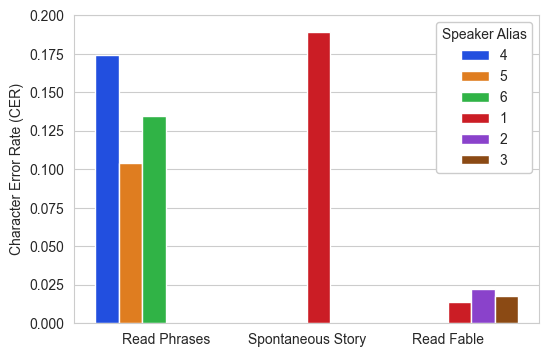

In [28]:
plt.figure(figsize=(6, 4))
sns.set_style('whitegrid')
ax = sns.barplot(x='dataset', y='cer', hue='speaker_alias', data=grouped_cer_data, 
                 palette='bright', order=["read_phrases", "spontaneous_story", "read_fable"], hue_order=['4', '5', '6', '1', '2', '3'], width=1)

# Customization
ax.set_yticks(np.arange(0.00, 0.21, 0.025))
plt.ylabel('Character Error Rate (CER)')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(labels=['Read Phrases', 'Spontaneous Story', 'Read Fable'])
ax.set(xlabel=None)
plt.legend(title='Speaker Alias', framealpha=1.0)
plt.margins(x=0.05)

plt.savefig("r_images/original_cer_final.svg")
plt.savefig("r_images/original_cer_final.pdf")

plt.show()

# Experiment 1

## Split for Finetuning

#### Allocate all of northwind and sun to 'test'

In [14]:
# nw_sentences_train, nw_sentences_test = train_test_split(nw_df_sents, test_size=0.3, random_state=3) #made sure sentences that were only one character apart were both in train set
# nw_sentences_test, nw_sentences_dev = train_test_split(nw_sentences_test, test_size=0.3, random_state=3)
nw_sentences_test = nw_df_sents

#### ~70% for train, ~20% for test, and ~10% for dev sets

In [15]:
read_sentences_train, read_sentences_test = train_test_split(read_df_sents, test_size=0.3, random_state=42)
read_sentences_test, read_sentences_dev = train_test_split(read_sentences_test, test_size=0.3, random_state=42)
spontaneous_sentences_train, spontaneous_sentences_test = train_test_split(spontaneous_df_sents, test_size=0.3, random_state=42)
spontaneous_sentences_test, spontaneous_sentences_dev = train_test_split(spontaneous_sentences_test, test_size=0.3, random_state=42)

In [16]:
all_train = read_sentences_train + spontaneous_sentences_train# + nw_sentences_train
all_dev = read_sentences_dev + spontaneous_sentences_dev# + nw_sentences_dev
all_test = read_sentences_test + spontaneous_sentences_test + nw_sentences_test

In [17]:
len(all_sents)

291

In [18]:
len(all_train), len(all_dev), len(all_test)

(196, 27, 68)

In [19]:
set(all_train).intersection(set(all_dev))

set()

In [20]:
set(all_train).intersection(set(all_test))

set()

In [21]:
set(all_dev).intersection(set(all_test))

set()

## Finetuning Setup

### ~Heavily~ inspired by https://huggingface.co/blog/mms_adapters

## Meta Model

In [22]:
model_id = "facebook/mms-1b-all"
processor = AutoProcessor.from_pretrained(model_id)
model = Wav2Vec2ForCTC.from_pretrained(model_id)

In [23]:
processor.tokenizer.set_target_lang("ess") # Akuzipik (St. Lawrence Island or Siberian Yupik) language code
model.load_adapter("ess")

In [24]:
existing_vocab_dict = processor.tokenizer.vocab['ess']

In [25]:
new_vocab = processor.tokenizer.vocab
new_vocab['ess'] = existing_vocab_dict

In [26]:
with open('vocab.json', 'w') as vocab_file:
    json.dump(new_vocab, vocab_file)

In [27]:
tokenizer = Wav2Vec2CTCTokenizer.from_pretrained("./", target_lang='ess')
tokenizer.vocab['ess']

{"'": 33,
 '-': 22,
 '0': 32,
 '1': 36,
 '2': 38,
 '3': 40,
 '4': 37,
 '5': 39,
 '6': 42,
 '7': 43,
 '8': 44,
 '9': 41,
 '</s>': 2,
 '<pad>': 0,
 '<s>': 1,
 '<unk>': 3,
 'a': 4,
 'b': 31,
 'c': 27,
 'd': 30,
 'e': 10,
 'f': 26,
 'g': 5,
 'h': 13,
 'i': 6,
 'j': 25,
 'k': 14,
 'l': 11,
 'm': 16,
 'n': 8,
 'o': 28,
 'p': 18,
 'q': 15,
 'r': 21,
 's': 17,
 't': 12,
 'u': 9,
 'v': 23,
 'w': 20,
 'x': 34,
 'y': 19,
 'z': 29,
 '|': 7,
 'ʼ': 45,
 '‐': 24,
 'ꞌ': 35}

In [28]:
feature_extractor = Wav2Vec2FeatureExtractor(feature_size=1, sampling_rate=16000, padding_value=0.0, do_normalize=True, return_attention_mask=True)
feature_extractor

Wav2Vec2FeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": true,
  "sampling_rate": 16000
}

In [29]:
processor = Wav2Vec2Processor(feature_extractor=feature_extractor, tokenizer=tokenizer)
processor

Wav2Vec2Processor:
- feature_extractor: Wav2Vec2FeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": true,
  "sampling_rate": 16000
}

- tokenizer: Wav2Vec2CTCTokenizer(name_or_path='./', vocab_size=46, model_max_length=1000000000000000019884624838656, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	1: AddedToken("<s>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	2: AddedToken("</s>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	3: AddedToken("<unk>", rstrip=True, lstrip=True, single_word=False, norm

In [30]:
train_dict_list = []
for sent in tqdm(all_train):
    for row in read_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            train_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    for row in spontaneous_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            train_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    for row in nw_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            train_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    

dev_dict_list = []
for sent in tqdm(all_dev):
    for row in read_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            dev_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    for row in spontaneous_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            dev_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    for row in nw_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            dev_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    

test_dict_list = []
new_test_df = pd.concat([nw_df, spontaneous_df]).reset_index(drop=True)
for sent in tqdm(all_test):
    for row in read_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            test_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    for row in spontaneous_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            test_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    for row in nw_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            test_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })

  0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/68 [00:00<?, ?it/s]

In [31]:
random.shuffle(train_dict_list)
random.shuffle(dev_dict_list)
random.shuffle(test_dict_list)

train_set = {"input_values": [], "input_length": [], "labels": []}
for a_dict in train_dict_list:
    for key, value in a_dict.items():
        train_set[key].append(value)

dev_set = {"input_values": [], "input_length": [], "labels": []}
for a_dict in dev_dict_list:
    for key, value in a_dict.items():
        dev_set[key].append(value)

test_set = {"input_values": [], "input_length": [], "labels": []}
for a_dict in test_dict_list:
    for key, value in a_dict.items():
        test_set[key].append(value)

In [32]:
train_set = Dataset.from_dict(train_set)
dev_set = Dataset.from_dict(dev_set)
test_set = Dataset.from_dict(test_set)

In [33]:
len(train_set), len(dev_set), len(test_set)

(408, 54, 151)

In [34]:
# Taken entirely from https://huggingface.co/blog/mms_adapters

@dataclass
class DataCollatorCTCWithPadding:
    """
    Data collator that will dynamically pad the inputs received.
    Args:
        processor (:class:`~transformers.Wav2Vec2Processor`)
            The processor used for proccessing the data.
        padding (:obj:`bool`, :obj:`str` or :class:`~transformers.tokenization_utils_base.PaddingStrategy`, `optional`, defaults to :obj:`True`):
            Select a strategy to pad the returned sequences (according to the model's padding side and padding index)
            among:
            * :obj:`True` or :obj:`'longest'`: Pad to the longest sequence in the batch (or no padding if only a single
              sequence if provided).
            * :obj:`'max_length'`: Pad to a maximum length specified with the argument :obj:`max_length` or to the
              maximum acceptable input length for the model if that argument is not provided.
            * :obj:`False` or :obj:`'do_not_pad'` (default): No padding (i.e., can output a batch with sequences of
              different lengths).
    """

    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # split inputs and labels since they have to be of different lengths and need
        # different padding methods
        input_features = [{"input_values": feature["input_values"]} for feature in features]
        label_features = [{"input_ids": feature["labels"]} for feature in features]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt",
        )

        labels_batch = self.processor.pad(
            labels=label_features,
            padding=self.padding,
            return_tensors="pt",
        )

        # replace padding with -100 to ignore loss correctly
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        batch["labels"] = labels

        return batch

In [35]:
data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)
data_collator

DataCollatorCTCWithPadding(processor=Wav2Vec2Processor:
- feature_extractor: Wav2Vec2FeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": true,
  "sampling_rate": 16000
}

- tokenizer: Wav2Vec2CTCTokenizer(name_or_path='./', vocab_size=46, model_max_length=1000000000000000019884624838656, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	1: AddedToken("<s>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	2: AddedToken("</s>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	3: AddedToken("<unk>", rstrip=True,

In [36]:
cer_metric = load("cer")
wer_metric = load("wer")

In [37]:
def compute_metrics(pred):
    pred_logits = pred.predictions
    pred_ids = np.argmax(pred_logits, axis=-1)
    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str = processor.batch_decode(pred_ids)
    # we do not want to group tokens when computing the metrics
    label_str = processor.batch_decode(pred.label_ids, group_tokens=False)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    return {"cer": cer}

In [38]:
model = Wav2Vec2ForCTC.from_pretrained(
    "facebook/mms-1b-all",
    attention_dropout=0.0,
    hidden_dropout=0.0,
    feat_proj_dropout=0.0,
    layerdrop=0.0,
    ctc_loss_reduction="mean",
    pad_token_id=processor.tokenizer.pad_token_id,
    vocab_size=len(processor.tokenizer),
    ignore_mismatched_sizes=True,
)

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/mms-1b-all and are newly initialized because the shapes did not match:
- lm_head.bias: found shape torch.Size([154]) in the checkpoint and torch.Size([46]) in the model instantiated
- lm_head.weight: found shape torch.Size([154, 1280]) in the checkpoint and torch.Size([46, 1280]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [39]:
model.load_adapter("ess")

In [40]:
model = model.to(device)

In [41]:
model.device

device(type='cuda', index=0)

In [42]:
#model.init_adapter_layers()
model.freeze_base_model()
adapter_weights = model._get_adapters()
for param in adapter_weights.values():
    param.requires_grad = True

In [43]:
training_args = TrainingArguments(
  output_dir='finetuning_model',
  group_by_length=True,
  per_device_train_batch_size=4,
  eval_strategy="steps",
  num_train_epochs=4,
  gradient_checkpointing=True,
  fp16=True,
  save_steps=100,
  eval_steps=50,
  logging_steps=50,
  learning_rate=1e-3,
  warmup_steps=50,
  save_total_limit=8,
  push_to_hub=False,
  use_cpu=False,
  load_best_model_at_end=True
)

In [44]:
trainer = Trainer(
    model=model,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_set,
    eval_dataset=dev_set,
    tokenizer=processor.feature_extractor
)

C:\Users\summe\AppData\Local\Temp\ipykernel_10116\1120500671.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [45]:
training_args.device

device(type='cuda', index=0)

In [46]:
train_df = pd.concat([df[df.SentenceText.isin(all_train)] for df in [read_df, spontaneous_df, nw_df]]).reset_index(drop=True)

In [47]:
dev_df = pd.concat([df[df.SentenceText.isin(all_dev)] for df in [read_df, spontaneous_df, nw_df]]).reset_index(drop=True)

In [48]:
test_df = pd.concat([df[df.SentenceText.isin(all_test)] for df in [read_df, spontaneous_df, nw_df]]).reset_index(drop=True)

In [49]:
train_df.duration.sum()/60, dev_df.duration.sum()/60, test_df.duration.sum()/60

(27.189551041666668, 3.1331354166666663, 12.181157291666667)

In [51]:
len(test_df)

151

In [52]:
len(test_df.SentenceText.unique())

68

In [53]:
full_df = pd.concat([train_df, dev_df, test_df]).reset_index(drop=True)

In [54]:
train_df.to_pickle('train_df_exp_1.pkl')
dev_df.to_pickle('dev_df_exp_1.pkl')
test_df.to_pickle('test_df_exp_1.pkl')

In [55]:
torch.cuda.empty_cache()

In [56]:
%%time
trainer.train()

Step,Training Loss,Validation Loss,Cer
50,0.772200,0.343848,0.101611
100,0.462900,0.379436,0.111524
150,0.370000,0.272073,0.099133
200,0.338100,0.301981,0.097893
250,0.294200,0.267765,0.086741
300,0.237200,0.262471,0.076828
350,0.241600,0.266210,0.078067
400,0.225200,0.268372,0.078067


CPU times: total: 3min 28s
Wall time: 4min 20s


TrainOutput(global_step=408, training_loss=0.36885086169429854, metrics={'train_runtime': 254.9413, 'train_samples_per_second': 6.401, 'train_steps_per_second': 1.6, 'total_flos': 6.285295039908869e+17, 'train_loss': 0.36885086169429854, 'epoch': 4.0})

In [57]:
best_checkpoint = trainer.state.best_model_checkpoint
print(best_checkpoint)

finetuning_model\checkpoint-300


In [58]:
# adapter_file = WAV2VEC2_ADAPTER_SAFE_FILE.format('ess')
# adapter_file = os.path.join(training_args.output_dir, adapter_file)

# safe_save_file(model._get_adapters(), adapter_file, metadata={"format": "pt"})

In [134]:
# trainer.save_model(f"final_finetuned/{best_checkpoint}")

## Reload and Use Finetuned Model

In [13]:
torch.cuda.empty_cache()

In [15]:
model = Wav2Vec2ForCTC.from_pretrained("./finetuning_model/checkpoint-300")
tokenizer = Wav2Vec2CTCTokenizer.from_pretrained("./", target_lang='ess')
feature_extractor = Wav2Vec2FeatureExtractor(feature_size=1, sampling_rate=16000, padding_value=0.0, do_normalize=True, return_attention_mask=True)
processor = Wav2Vec2Processor(feature_extractor=feature_extractor, tokenizer=tokenizer)

In [16]:
device = torch.device("cuda")
model = model.to(device)

In [17]:
torch.cuda.empty_cache()

In [28]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

In [30]:
train_df = pd.read_pickle('train_df_exp_1.pkl')
dev_df = pd.read_pickle('dev_df_exp_1.pkl')
test_df = pd.read_pickle('test_df_exp_1.pkl')

In [20]:
trans_dict = {}
logit_dict = {}
for row in tqdm(test_df.itertuples(), total=len(test_df)):
    try:
        data, sr = sf.read(row.audio_path)
        inputs = processor(data, sampling_rate=sr, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs).logits
        logit_dict[row.audio_path] = outputs.cpu().numpy()
        ids = torch.argmax(outputs, dim=-1)[0]
        transcription = processor.decode(ids)
        trans_dict[row.audio_path] = transcription
    except Exception as e:
        print(e, row.Index)

  0%|          | 0/151 [00:00<?, ?it/s]

In [21]:
test_df['FinetunedTranscript'] = test_df['audio_path'].map(trans_dict)
test_df['FinetunedTranscript'] = test_df['FinetunedTranscript'].apply(clean_sentence)
test_df['FinetunedLogits'] = test_df['audio_path'].map(logit_dict)
test_df.to_csv('test_df_exp_1.csv', index=False)
test_df.to_pickle('test_df_exp_1.pkl')

In [98]:
cer_list = []
wer_list = []
for row in tqdm(test_df.itertuples(), total=len(test_df)):
    cer_list.append(cer_metric.compute(predictions=[row.FinetunedTranscript], references=[row.SentenceText]))
    wer_list.append(wer_metric.compute(predictions=[row.FinetunedTranscript], references=[row.SentenceText]))

test_df['cer_finetuned'] = cer_list
test_df['wer_finetuned'] = wer_list

  0%|          | 0/151 [00:00<?, ?it/s]

In [15]:
test_df.cer.mean()

0.143110341916715

In [20]:
test_df[test_df.dataset=="spontaneous_story"].cer_finetuned.mean()

0.1314773347283041

In [16]:
test_df.cer_finetuned.mean()

0.0877839405764097

In [17]:
test_df.wer.mean()

0.7107011458004836

In [18]:
test_df.wer_finetuned.mean()

0.5893592978030063

In [29]:
test_df = pd.read_pickle('test_df_exp_1.pkl')

In [30]:
grouped_test_cer_data = test_df.groupby(['dataset', 'speaker_alias']).cer_finetuned.mean().reset_index()

In [31]:
grouped_test_cer_data = grouped_test_cer_data.sort_values(by='dataset')

In [32]:
grouped_test_cer_data

,dataset,speaker_alias,cer_finetuned
0,read_fable,1,0.058395
1,read_fable,2,0.050374
2,read_fable,3,0.053113
3,read_phrases,4,0.078939
4,read_phrases,5,0.079949
5,read_phrases,6,0.071527
6,spontaneous_story,1,0.131477


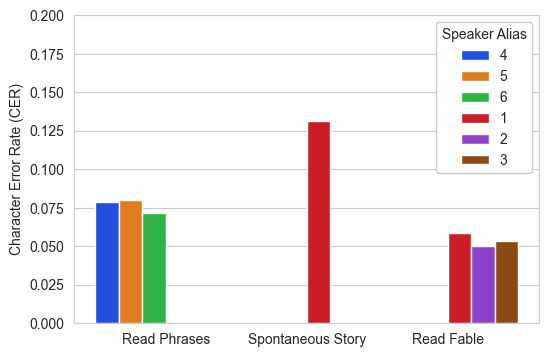

In [33]:
plt.figure(figsize=(6, 4))
sns.set_style('whitegrid')
ax = sns.barplot(x='dataset', y='cer_finetuned', hue='speaker_alias', data=grouped_test_cer_data, 
                 palette='bright', order=["read_phrases", "spontaneous_story", "read_fable"], hue_order=['4', '5', '6', '1', '2', '3'], width=1)

# Customization
ax.set_yticks(np.arange(0.00, 0.21, 0.025))
plt.ylabel('Character Error Rate (CER)')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(labels=['Read Phrases', 'Spontaneous Story', 'Read Fable'])
ax.set(xlabel=None)
plt.legend(title='Speaker Alias', framealpha=1.0)
plt.margins(x=0.05)

plt.savefig("r_images/speaker_grouped_finetuned_cer.svg")
plt.savefig("r_images/speaker_grouped_finetuned_cer.pdf") 

plt.show()

# Experiment 2

## Split for finetuning

### Only spontaneous speech in dev/test, all read speech and northwind and sun read speech in train

In [15]:
nw_sentences_train = nw_df_sents
read_sentences_train = read_df_sents

In [16]:
spontaneous_sentences_dev, spontaneous_sentences_test = train_test_split(spontaneous_df_sents, test_size=0.78, random_state=42)

In [17]:
all_train = read_sentences_train + nw_sentences_train
all_dev = spontaneous_sentences_dev
all_test = spontaneous_sentences_test

In [18]:
len(all_sents)

291

In [19]:
len(all_train), len(all_dev), len(all_test)

(96, 42, 153)

In [20]:
set(all_train).intersection(set(all_dev))

set()

In [21]:
set(all_train).intersection(set(all_test))

set()

In [22]:
set(all_dev).intersection(set(all_test))

set()

## Finetuning Setup

### ~Heavily~ inspired by https://huggingface.co/blog/mms_adapters

## Meta Model

In [23]:
model_id = "facebook/mms-1b-all"
processor = AutoProcessor.from_pretrained(model_id)
model = Wav2Vec2ForCTC.from_pretrained(model_id)

In [24]:
processor.tokenizer.set_target_lang("ess") # Akuzipik (St. Lawrence Island or Siberian Yupik) language code
model.load_adapter("ess")

In [25]:
existing_vocab_dict = processor.tokenizer.vocab['ess']

In [26]:
new_vocab = processor.tokenizer.vocab
new_vocab['ess'] = existing_vocab_dict

In [27]:
with open('vocab.json', 'w') as vocab_file:
    json.dump(new_vocab, vocab_file)

In [28]:
tokenizer = Wav2Vec2CTCTokenizer.from_pretrained("./", target_lang='ess')
tokenizer.vocab['ess']

{"'": 33,
 '-': 22,
 '0': 32,
 '1': 36,
 '2': 38,
 '3': 40,
 '4': 37,
 '5': 39,
 '6': 42,
 '7': 43,
 '8': 44,
 '9': 41,
 '</s>': 2,
 '<pad>': 0,
 '<s>': 1,
 '<unk>': 3,
 'a': 4,
 'b': 31,
 'c': 27,
 'd': 30,
 'e': 10,
 'f': 26,
 'g': 5,
 'h': 13,
 'i': 6,
 'j': 25,
 'k': 14,
 'l': 11,
 'm': 16,
 'n': 8,
 'o': 28,
 'p': 18,
 'q': 15,
 'r': 21,
 's': 17,
 't': 12,
 'u': 9,
 'v': 23,
 'w': 20,
 'x': 34,
 'y': 19,
 'z': 29,
 '|': 7,
 'ʼ': 45,
 '‐': 24,
 'ꞌ': 35}

In [29]:
feature_extractor = Wav2Vec2FeatureExtractor(feature_size=1, sampling_rate=16000, padding_value=0.0, do_normalize=True, return_attention_mask=True)
feature_extractor

Wav2Vec2FeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": true,
  "sampling_rate": 16000
}

In [30]:
processor = Wav2Vec2Processor(feature_extractor=feature_extractor, tokenizer=tokenizer)
processor

Wav2Vec2Processor:
- feature_extractor: Wav2Vec2FeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": true,
  "sampling_rate": 16000
}

- tokenizer: Wav2Vec2CTCTokenizer(name_or_path='./', vocab_size=46, model_max_length=1000000000000000019884624838656, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	1: AddedToken("<s>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	2: AddedToken("</s>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	3: AddedToken("<unk>", rstrip=True, lstrip=True, single_word=False, norm

In [31]:
train_dict_list = []
for sent in tqdm(all_train):
    for row in read_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            train_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    for row in spontaneous_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            train_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    for row in nw_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            train_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    

dev_dict_list = []
for sent in tqdm(all_dev):
    for row in read_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            dev_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    for row in spontaneous_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            dev_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    for row in nw_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            dev_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    

test_dict_list = []
new_test_df = pd.concat([nw_df, spontaneous_df]).reset_index(drop=True)
for sent in tqdm(all_test):
    for row in read_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            test_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    for row in spontaneous_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            test_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })
    for row in nw_df.itertuples():
        if row.SentenceText == sent:
            audio_data, sr = sf.read(row.audio_path)
            input_values = processor(audio_data, sampling_rate=sr).input_values[0]
            test_dict_list.append({
                'input_values': input_values,
                'input_length': len(input_values),
                'labels': processor(text=sent).input_ids
            })

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/153 [00:00<?, ?it/s]

In [32]:
random.shuffle(train_dict_list)
random.shuffle(dev_dict_list)
random.shuffle(test_dict_list)

train_set = {"input_values": [], "input_length": [], "labels": []}
for a_dict in train_dict_list:
    for key, value in a_dict.items():
        train_set[key].append(value)

dev_set = {"input_values": [], "input_length": [], "labels": []}
for a_dict in dev_dict_list:
    for key, value in a_dict.items():
        dev_set[key].append(value)

test_set = {"input_values": [], "input_length": [], "labels": []}
for a_dict in test_dict_list:
    for key, value in a_dict.items():
        test_set[key].append(value)

In [33]:
train_set = Dataset.from_dict(train_set)
dev_set = Dataset.from_dict(dev_set)
test_set = Dataset.from_dict(test_set)

In [34]:
len(train_set), len(dev_set), len(test_set)

(418, 42, 153)

In [35]:
# Taken entirely from https://huggingface.co/blog/mms_adapters

@dataclass
class DataCollatorCTCWithPadding:
    """
    Data collator that will dynamically pad the inputs received.
    Args:
        processor (:class:`~transformers.Wav2Vec2Processor`)
            The processor used for proccessing the data.
        padding (:obj:`bool`, :obj:`str` or :class:`~transformers.tokenization_utils_base.PaddingStrategy`, `optional`, defaults to :obj:`True`):
            Select a strategy to pad the returned sequences (according to the model's padding side and padding index)
            among:
            * :obj:`True` or :obj:`'longest'`: Pad to the longest sequence in the batch (or no padding if only a single
              sequence if provided).
            * :obj:`'max_length'`: Pad to a maximum length specified with the argument :obj:`max_length` or to the
              maximum acceptable input length for the model if that argument is not provided.
            * :obj:`False` or :obj:`'do_not_pad'` (default): No padding (i.e., can output a batch with sequences of
              different lengths).
    """

    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # split inputs and labels since they have to be of different lengths and need
        # different padding methods
        input_features = [{"input_values": feature["input_values"]} for feature in features]
        label_features = [{"input_ids": feature["labels"]} for feature in features]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt",
        )

        labels_batch = self.processor.pad(
            labels=label_features,
            padding=self.padding,
            return_tensors="pt",
        )

        # replace padding with -100 to ignore loss correctly
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        batch["labels"] = labels

        return batch

In [36]:
data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)
data_collator

DataCollatorCTCWithPadding(processor=Wav2Vec2Processor:
- feature_extractor: Wav2Vec2FeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": true,
  "sampling_rate": 16000
}

- tokenizer: Wav2Vec2CTCTokenizer(name_or_path='./', vocab_size=46, model_max_length=1000000000000000019884624838656, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	1: AddedToken("<s>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	2: AddedToken("</s>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	3: AddedToken("<unk>", rstrip=True,

In [37]:
cer_metric = load("cer")
wer_metric = load("wer")

In [38]:
def compute_metrics(pred):
    pred_logits = pred.predictions
    pred_ids = np.argmax(pred_logits, axis=-1)
    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str = processor.batch_decode(pred_ids)
    # we do not want to group tokens when computing the metrics
    label_str = processor.batch_decode(pred.label_ids, group_tokens=False)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    return {"cer": cer}

In [39]:
model = Wav2Vec2ForCTC.from_pretrained(
    "facebook/mms-1b-all",
    attention_dropout=0.0,
    hidden_dropout=0.0,
    feat_proj_dropout=0.0,
    layerdrop=0.0,
    ctc_loss_reduction="mean",
    pad_token_id=processor.tokenizer.pad_token_id,
    vocab_size=len(processor.tokenizer),
    ignore_mismatched_sizes=True,
)

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/mms-1b-all and are newly initialized because the shapes did not match:
- lm_head.bias: found shape torch.Size([154]) in the checkpoint and torch.Size([46]) in the model instantiated
- lm_head.weight: found shape torch.Size([154, 1280]) in the checkpoint and torch.Size([46, 1280]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [40]:
model.load_adapter("ess")

In [41]:
model = model.to(device)

In [42]:
model.device

device(type='cuda', index=0)

In [43]:
#model.init_adapter_layers()
model.freeze_base_model()
adapter_weights = model._get_adapters()
for param in adapter_weights.values():
    param.requires_grad = True

In [44]:
training_args = TrainingArguments(
  output_dir='finetuning_read_speech_model',
  group_by_length=True,
  per_device_train_batch_size=4,
  eval_strategy="steps",
  num_train_epochs=4,
  gradient_checkpointing=True,
  fp16=True,
  save_steps=100,
  eval_steps=50,
  logging_steps=50,
  learning_rate=1e-3,
  warmup_steps=50,
  save_total_limit=8,
  push_to_hub=False,
  use_cpu=False,
  load_best_model_at_end=True
)

In [45]:
trainer = Trainer(
    model=model,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_set,
    eval_dataset=dev_set,
    tokenizer=processor.feature_extractor
)

C:\Users\summe\AppData\Local\Temp\ipykernel_23432\1120500671.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [46]:
training_args.device

device(type='cuda', index=0)

In [47]:
train_df = pd.concat([df[df.SentenceText.isin(all_train)] for df in [read_df, spontaneous_df, nw_df]]).reset_index(drop=True)

In [48]:
dev_df = pd.concat([df[df.SentenceText.isin(all_dev)] for df in [read_df, spontaneous_df, nw_df]]).reset_index(drop=True)

In [49]:
test_df = pd.concat([df[df.SentenceText.isin(all_test)] for df in [read_df, spontaneous_df, nw_df]]).reset_index(drop=True)

In [50]:
train_df.duration.sum()/60, dev_df.duration.sum()/60, test_df.duration.sum()/60

(30.185889583333335, 2.83606875, 9.481885416666666)

In [52]:
len(test_df)

153

In [53]:
len(test_df.SentenceText.unique())

153

In [54]:
full_df = pd.concat([train_df, dev_df, test_df]).reset_index(drop=True)

In [55]:
train_df.to_pickle('train_df_exp_2.pkl')
dev_df.to_pickle('dev_df_exp_2.pkl')
test_df.to_pickle('test_df_exp_2.pkl')

In [56]:
torch.cuda.empty_cache()

In [57]:
%%time
trainer.train()

Step,Training Loss,Validation Loss,Cer
50,0.672100,0.647487,0.151559
100,0.354200,0.656709,0.158811
150,0.182000,0.856918,0.160986
200,0.189300,0.621388,0.143582
250,0.095100,0.704249,0.153009
300,0.126700,0.757509,0.160986
350,0.115400,0.697647,0.153735
400,0.095700,0.714288,0.153735


CPU times: total: 3min 18s
Wall time: 4min 33s


TrainOutput(global_step=420, training_loss=0.22234412147885277, metrics={'train_runtime': 267.0068, 'train_samples_per_second': 6.262, 'train_steps_per_second': 1.573, 'total_flos': 7.029063454739023e+17, 'train_loss': 0.22234412147885277, 'epoch': 4.0})

In [58]:
best_checkpoint = trainer.state.best_model_checkpoint
print(best_checkpoint)

finetuning_read_speech_model\checkpoint-200


In [59]:
# adapter_file = WAV2VEC2_ADAPTER_SAFE_FILE.format('ess')
# adapter_file = os.path.join(training_args.output_dir, adapter_file)

# safe_save_file(model._get_adapters(), adapter_file, metadata={"format": "pt"})

In [135]:
# trainer.save_model(f"./{best_checkpoint}")

## Reload and Use Finetuned Model

In [62]:
torch.cuda.empty_cache()

In [63]:
model = Wav2Vec2ForCTC.from_pretrained(f"finetuning_read_speech_model/checkpoint-200")
tokenizer = Wav2Vec2CTCTokenizer.from_pretrained("./", target_lang='ess')
feature_extractor = Wav2Vec2FeatureExtractor(feature_size=1, sampling_rate=16000, padding_value=0.0, do_normalize=True, return_attention_mask=True)
processor = Wav2Vec2Processor(feature_extractor=feature_extractor, tokenizer=tokenizer)

In [64]:
device = torch.device("cuda")
model = model.to(device)

In [65]:
torch.cuda.empty_cache()

In [66]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

In [67]:
trans_dict = {}
logit_dict = {}
for row in tqdm(test_df.itertuples(), total=len(test_df)):
    try:
        data, sr = sf.read(row.audio_path)
        inputs = processor(data, sampling_rate=sr, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs).logits
        logit_dict[row.audio_path] = outputs.cpu().numpy()
        ids = torch.argmax(outputs, dim=-1)[0]
        transcription = processor.decode(ids)
        trans_dict[row.audio_path] = transcription
    except Exception as e:
        print(e, row.Index)

  0%|          | 0/153 [00:00<?, ?it/s]

In [68]:
test_df['ReadFinetunedTranscript'] = test_df['audio_path'].map(trans_dict)
test_df['ReadFinetunedTranscript'] = test_df['ReadFinetunedTranscript'].apply(clean_sentence)
test_df['ReadFinetunedLogits'] = test_df['audio_path'].map(logit_dict)
test_df.to_csv('test_df_exp_2.csv', index=False)
test_df.to_pickle('test_df_exp_2.pkl')

In [73]:
cer_list = []
wer_list = []
for row in tqdm(test_df.itertuples(), total=len(test_df)):
    cer_list.append(cer_metric.compute(predictions=[row.ReadFinetunedTranscript], references=[row.SentenceText]))
    wer_list.append(wer_metric.compute(predictions=[row.ReadFinetunedTranscript], references=[row.SentenceText]))

test_df['cer_read_finetuned'] = cer_list
test_df['wer_read_finetuned'] = wer_list

  0%|          | 0/153 [00:00<?, ?it/s]

In [35]:
test_df = pd.read_pickle('test_df_exp_2.pkl')

In [74]:
test_df.cer.mean()

0.2056479447316702

In [78]:
test_df.wer.mean()

0.8716542172424525

In [75]:
test_df.cer_read_finetuned.mean()

0.1725493878564614

In [77]:
test_df.wer_read_finetuned.mean()

0.8528789293495176

In [76]:
test_df.to_pickle('test_df_exp_2.pkl')

# Error Analysis

In [8]:
train_df = pd.read_pickle('train_df_exp_1.pkl')
dev_df = pd.read_pickle('dev_df_exp_1.pkl')
test_df = pd.read_pickle('test_df_exp_1.pkl')

In [9]:
spont_only_df = pd.read_pickle('test_df_exp_2.pkl')

In [10]:
test_df.cer.mean()

0.143110341916715

In [11]:
test_df.cer_finetuned.mean()

0.0877839405764097

In [110]:
def undouble_vowels(a_string):
    return re.sub(r'([aiouAIOU])\1+', r'\1', a_string)

In [111]:
test_df['cer_undouble_vowels'] = test_df.progress_apply(lambda x: cer_metric.compute(
    predictions=[undouble_vowels(x.MetaTranscript)],
    references=[undouble_vowels(x.SentenceText)]
    ), axis=1)

  0%|          | 0/151 [00:00<?, ?it/s]

In [112]:
test_df['wer_undouble_vowels'] = test_df.progress_apply(lambda x: wer_metric.compute(
    predictions=[undouble_vowels(x.MetaTranscript)],
    references=[undouble_vowels(x.SentenceText)]
    ), axis=1)

  0%|          | 0/151 [00:00<?, ?it/s]

In [113]:
test_df['cer_finetuned_undouble_vowels'] = test_df.progress_apply(lambda x: cer_metric.compute(
    predictions=[undouble_vowels(x.FinetunedTranscript)],
    references=[undouble_vowels(x.SentenceText)]
    ), axis=1)

  0%|          | 0/151 [00:00<?, ?it/s]

In [114]:
test_df['wer_finetuned_undouble_vowels'] = test_df.progress_apply(lambda x: wer_metric.compute(
    predictions=[undouble_vowels(x.FinetunedTranscript)],
    references=[undouble_vowels(x.SentenceText)]
    ), axis=1)

  0%|          | 0/151 [00:00<?, ?it/s]

In [115]:
test_df.wer_finetuned.mean()

0.5893592978030063

In [116]:
test_df.wer_finetuned_undouble_vowels.mean()

0.353319142226427

In [117]:
test_df.cer_finetuned.mean()

0.0877839405764097

In [118]:
test_df.cer_finetuned_undouble_vowels.mean()

0.049657939554437106

In [119]:
spont_only_df['cer_finetuned_undouble_vowels'] = spont_only_df.progress_apply(lambda x: cer_metric.compute(
    predictions=[undouble_vowels(x.ReadFinetunedTranscript)],
    references=[undouble_vowels(x.SentenceText)]
    ), axis=1)

  0%|          | 0/153 [00:00<?, ?it/s]

In [120]:
spont_only_df['wer_finetuned_undouble_vowels'] = spont_only_df.progress_apply(lambda x: wer_metric.compute(
    predictions=[undouble_vowels(x.ReadFinetunedTranscript)],
    references=[undouble_vowels(x.SentenceText)]
    ), axis=1)

  0%|          | 0/153 [00:00<?, ?it/s]

In [122]:
spont_only_df.wer_read_finetuned.mean()

0.8528789293495176

In [123]:
spont_only_df.wer_finetuned_undouble_vowels.mean()

0.7818160597572361

In [124]:
spont_only_df.cer_read_finetuned.mean()

0.1725493878564614

In [125]:
spont_only_df.cer_finetuned_undouble_vowels.mean()

0.15147327938055413

In [12]:
new_df = test_df.groupby('dataset')[['cer', 'cer_finetuned']].mean().unstack().reset_index()
new_df = new_df.rename({0: 'cer', 'level_0': 'model'}, axis=1)
new_df['model'] = new_df['model'].map({'cer':'Original Meta', 'cer_finetuned':'Finetuned-All'})

In [13]:
spont_only_df['dataset'] = 'spontaneous_story'
new_df2 = spont_only_df.groupby('dataset')[['cer', 'cer_read_finetuned']].mean().unstack().reset_index()
new_df2 = new_df2.rename({0: 'cer', 'level_0': 'model'}, axis=1)
new_df2['model'] = new_df2['model'].map({'cer':'Original Meta', 'cer_read_finetuned':'Finetuned-Read-Speech-Only'})
new_df2 = new_df2[new_df2.model=='Finetuned-Read-Speech-Only']

In [14]:
newest_df = pd.concat([new_df, new_df2])

In [15]:
newest_df.sort_values(by='dataset')

,model,dataset,cer
0,Original Meta,read_fable,0.031097
3,Finetuned-All,read_fable,0.053961
1,Original Meta,read_phrases,0.142675
4,Finetuned-All,read_phrases,0.076392
2,Original Meta,spontaneous_story,0.209593
5,Finetuned-All,spontaneous_story,0.131477
1,Finetuned-Read-Speech-Only,spontaneous_story,0.172549


C:\Users\summe\AppData\Local\Temp\ipykernel_23432\354736241.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=['Read Phrases', 'Read Fable', 'Spontaneous Story'])


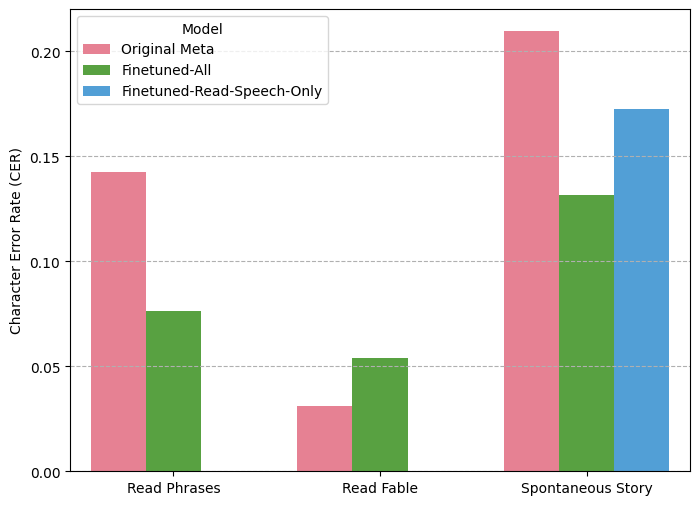

In [138]:
import matplotlib.ticker as ticker
# Create the grouped boxplot
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
ax = sns.barplot(x='dataset', y='cer', hue='model', data=newest_df, palette='husl', order=["read_phrases", "read_fable", "spontaneous_story"])

# Display the plot
# plt.title('Mean ASR Error Rates on Read and Spontaneous Speech')
plt.legend(title='Model') # Add a legend for the 'hue' variable
# ax.get_xaxis().set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.grid(axis='y', linestyle='--')
plt.ylabel('Character Error Rate (CER)')
ax.set_xticklabels(labels=['Read Phrases', 'Read Fable', 'Spontaneous Story'])
ax.set(xlabel=None)
# plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig("r_images/finetuned_cer_means_final.svg")
plt.savefig("r_images/finetuned_cer_means_final.pdf")

plt.show()

In [140]:
new_df = test_df.groupby('dataset')[['wer', 'wer_finetuned']].mean().unstack().reset_index()
new_df = new_df.rename({0: 'wer', 'level_0': 'model'}, axis=1)
new_df['model'] = new_df['model'].map({'wer':'Original Meta', 'wer_finetuned':'Finetuned-All'})

In [142]:
spont_only_df['dataset'] = 'spontaneous_story'
new_df2 = spont_only_df.groupby('dataset')[['wer', 'wer_read_finetuned']].mean().unstack().reset_index()
new_df2 = new_df2.rename({0: 'wer', 'level_0': 'model'}, axis=1)
new_df2['model'] = new_df2['model'].map({'wer':'Original Meta', 'wer_read_finetuned':'Finetuned-Read-Speech-Only'})
new_df2 = new_df2[new_df2.model=='Finetuned-Read-Speech-Only']

In [143]:
newest_df = pd.concat([new_df, new_df2])

In [144]:
newest_df

,model,dataset,wer
0,Original Meta,read_fable,0.245949
1,Original Meta,read_phrases,0.732558
2,Original Meta,spontaneous_story,0.936905
3,Finetuned-All,read_fable,0.510979
4,Finetuned-All,read_phrases,0.511628
5,Finetuned-All,spontaneous_story,0.798287
1,Finetuned-Read-Speech-Only,spontaneous_story,0.852879


C:\Users\summe\AppData\Local\Temp\ipykernel_23432\2008992442.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=['Read Phrases', 'Read Fable', 'Spontaneous Story'])


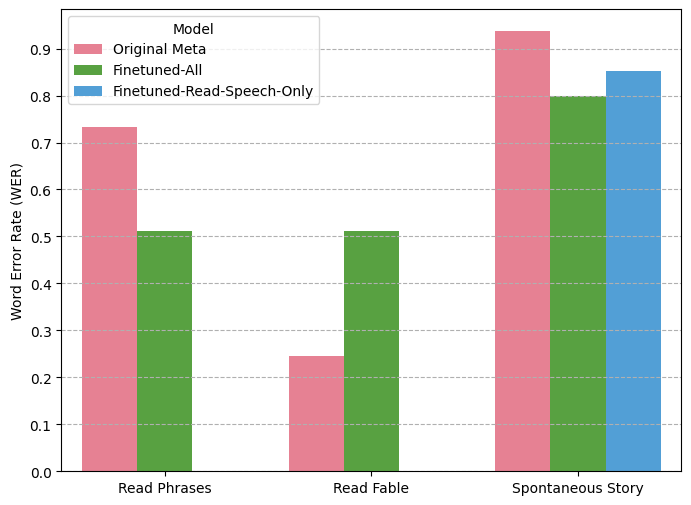

In [145]:
import matplotlib.ticker as ticker
# Create the grouped boxplot
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
ax = sns.barplot(x='dataset', y='wer', hue='model', data=newest_df, palette='husl', order=["read_phrases", "read_fable", "spontaneous_story"])


# Display the plot
# plt.title('Mean ASR Error Rates on Read and Spontaneous Speech')
plt.legend(title='Model') # Add a legend for the 'hue' variable
# ax.get_xaxis().set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.10))
ax.grid(axis='y', linestyle='--')
plt.ylabel('Word Error Rate (WER)')
ax.set_xticklabels(labels=['Read Phrases', 'Read Fable', 'Spontaneous Story'])
ax.set(xlabel=None)
# plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig("r_images/finetuned_wer_means_final.svg")
plt.savefig("r_images/finetuned_wer_means_final.pdf")

plt.show()

## Most Common Error Types

In [152]:
test_df.cer.mean()

0.143110341916715

In [153]:
test_df.cer_finetuned.mean()

0.0877839405764097

In [155]:
test_df[test_df.dataset=='spontaneous_story'].cer.mean()

0.20959257964504838

In [156]:
test_df[test_df.dataset=='spontaneous_story'].cer_finetuned.mean()

0.1314773347283041

In [157]:
error_df = full_df[full_df.cer!=0]

In [158]:
meta_error_df = test_df[test_df.cer!=0].reset_index()
finetuned_error_df = test_df[test_df.cer_finetuned!=0].reset_index()

In [159]:
len(meta_error_df), len(finetuned_error_df)

(130, 113)

In [160]:
len(error_df)

518

In [161]:
consonants = 'bcdfghjklmnpqrstvwxyz'
vowels = 'aiue' #e cannot be long

In [ ]:
def deduplicate_all_vowels(a_string):
    return re.sub(r'([aiue]+)\1+', r'\1', a_string)

def deduplicate_and_pad_all_vowels(a_string):
    new_string = re.sub(r'([aiue]+)\1+', r'\1-', a_string)
    return re.sub(r'([aiue]+)(?!-)\1*', r'\1-', new_string)

def replace_all_vowels_with_something(a_string, replacement):
    return re.sub(r'([aiue]+)', replacement, a_string)

In [223]:
def contains_vowel_length_issues(transcript, reference):
    current_cer = cer_metric.compute(predictions=[transcript], references=[reference])
    # print(current_cer)
    if current_cer == 0:
        return False
    new_transcript = deduplicate_and_pad_all_vowels(transcript)
    new_reference = deduplicate_and_pad_all_vowels(reference)
    new_cer = cer_metric.compute(predictions=[new_transcript], references=[new_reference])
    # print(new_cer)
    # print(new_transcript, new_reference)
    if new_cer < current_cer:
        return True
    elif new_cer == current_cer:
        # print(transcript)
        # print(reference)
        # print('-----------\n')
        return False
    elif new_cer > current_cer:
        return False
    
def contains_spacing_issues(transcript, reference):
    current_cer = cer_metric.compute(predictions=[transcript], references=[reference])
    # print(current_cer)
    if current_cer == 0:
        return False
    new_transcript = re.sub(r'\s+', '', transcript)
    new_reference = re.sub(r'\s+', '', reference)
    new_cer = cer_metric.compute(predictions=[new_transcript], references=[new_reference])
    # print(new_cer)
    # print(new_transcript, new_reference)
    if new_cer < current_cer:
        return True
    elif new_cer == current_cer:
        # print(transcript)
        # print(reference)
        # print('-----------\n')
        return False
    elif new_cer > current_cer:
        return False
    
def contains_consonant_issues(transcript, reference):
    current_cer = cer_metric.compute(predictions=[transcript], references=[reference])
    # print(current_cer)
    if current_cer == 0:
        return False
    new_transcript = re.sub(r'[bcdfghjklmnpqrstvwxyz]+', '', transcript)
    new_reference = re.sub(r'[bcdfghjklmnpqrstvwxyz]+', '', reference)
    new_cer = cer_metric.compute(predictions=[new_transcript], references=[new_reference])
    if new_cer < current_cer:
        return True
    elif new_cer == current_cer:
        # print(transcript)
        # print(reference)
        # print('-----------\n')
        return False
    elif new_cer > current_cer:
        return False
    
def missing_extra_or_wrong_vowels(transcript, reference):
    current_cer = cer_metric.compute(predictions=[transcript], references=[reference])
    # print(current_cer)
    if current_cer == 0:
        return False
    new_transcript = deduplicate_and_pad_all_vowels(transcript)
    new_reference = deduplicate_and_pad_all_vowels(reference)
    new_cer = cer_metric.compute(predictions=[new_transcript], references=[new_reference])
    newest_transcript = replace_all_vowels_with_something(new_transcript, '').replace('-', '')
    newest_reference = replace_all_vowels_with_something(new_reference, '').replace('-', '')
    newest_cer = cer_metric.compute(predictions=[newest_transcript], references=[newest_reference])
    # print(new_cer)
    # print(new_transcript, new_reference)
    if newest_cer < new_cer:
        return True
    elif newest_cer == new_cer:
        # print(transcript)
        # print(reference)
        # print('-----------\n')
        return False
    elif newest_cer > new_cer:
        return False

In [258]:
meta_error_df['missing_extra_or_wrong_vowels'] = meta_error_df.progress_apply(lambda x: missing_extra_or_wrong_vowels(x.MetaTranscript, x.SentenceText), axis=1)
finetuned_error_df['missing_extra_or_wrong_vowels'] = finetuned_error_df.progress_apply(lambda x: missing_extra_or_wrong_vowels(x.FinetunedTranscript, x.SentenceText), axis=1)

  0%|          | 0/130 [00:00<?, ?it/s]

  0%|          | 0/113 [00:00<?, ?it/s]

In [259]:
meta_error_df['contains_consonant_issues'] = meta_error_df.progress_apply(lambda x: contains_consonant_issues(x.MetaTranscript, x.SentenceText), axis=1)
finetuned_error_df['contains_consonant_issues'] = finetuned_error_df.progress_apply(lambda x: contains_consonant_issues(x.FinetunedTranscript, x.SentenceText), axis=1)

  0%|          | 0/130 [00:00<?, ?it/s]

  0%|          | 0/113 [00:00<?, ?it/s]

In [260]:
meta_error_df['contains_spacing_issues'] = meta_error_df.progress_apply(lambda x: contains_spacing_issues(x.MetaTranscript, x.SentenceText), axis=1)
finetuned_error_df['contains_spacing_issues'] = finetuned_error_df.progress_apply(lambda x: contains_spacing_issues(x.FinetunedTranscript, x.SentenceText), axis=1)

  0%|          | 0/130 [00:00<?, ?it/s]

  0%|          | 0/113 [00:00<?, ?it/s]

In [261]:
meta_error_df['contains_vowel_length_issues'] = meta_error_df.progress_apply(lambda x: contains_vowel_length_issues(x.MetaTranscript, x.SentenceText), axis=1)
finetuned_error_df['contains_vowel_length_issues'] = finetuned_error_df.progress_apply(lambda x: contains_vowel_length_issues(x.FinetunedTranscript, x.SentenceText), axis=1)

  0%|          | 0/130 [00:00<?, ?it/s]

  0%|          | 0/113 [00:00<?, ?it/s]

In [262]:
len(meta_error_df)/len(test_df) #86.1% of data had at least one character error

0.8609271523178808

In [263]:
len(finetuned_error_df)/len(test_df) #74.8% of data had at least one character error

0.7483443708609272

In [264]:
len(meta_error_df[meta_error_df.contains_vowel_length_issues == True])/len(test_df) #77.5% of data had at least one issue with vowel length

0.7748344370860927

In [265]:
len(finetuned_error_df[finetuned_error_df.contains_vowel_length_issues == True])/len(test_df) #69.5% of data had at least one issue with vowel length

0.695364238410596

In [266]:
len(meta_error_df[meta_error_df.contains_spacing_issues == True])/len(test_df) # 20.5% of data had issue with word boundaries

0.2052980132450331

In [267]:
len(finetuned_error_df[finetuned_error_df.contains_spacing_issues == True])/len(test_df) # 15.9% of data had issue with word boundaries

0.15894039735099338

In [268]:
len(meta_error_df[meta_error_df.contains_consonant_issues == True])/len(test_df) # 13.2% of data had issue with consonants

0.13245033112582782

In [269]:
len(finetuned_error_df[finetuned_error_df.contains_consonant_issues == True])/len(test_df) # 8.6% of data had issues with consonants

0.08609271523178808

In [270]:
len(meta_error_df[meta_error_df.missing_extra_or_wrong_vowels == True])/len(test_df) # 34.4% of data had extra/missing/wrong vowels (aside from length)

0.3443708609271523

In [271]:
len(finetuned_error_df[finetuned_error_df.missing_extra_or_wrong_vowels == True])/len(test_df) # 27.2% of data had extra/missing/wrong vowels (aside from length)

0.271523178807947

### Most frequent characters in corpus

In [181]:
full_corpus = ' '.join(list(set(all_sents)))
full_chars = full_corpus.replace(' ', '')
akuzipik_char_counts = Counter(list(full_chars))

In [182]:
full_chars.count('ghh')

27

In [ ]:
sorted_akuzipik_char_counts = sorted(akuzipik_char_counts.items(), key=lambda item: item[1], reverse=True)
akuzipik_ranks = list(range(1, len(sorted_akuzipik_char_counts) + 1))
akuzipik_frequencies = [count for word, count in sorted_akuzipik_char_counts]

In [184]:
sorted_akuzipik_char_counts

[('a', 1455),
 ('g', 799),
 ('n', 663),
 ('i', 663),
 ('t', 565),
 ('u', 554),
 ('l', 551),
 ('e', 471),
 ('h', 435),
 ('k', 374),
 ('q', 269),
 ('m', 206),
 ('s', 152),
 ('w', 130),
 ('p', 111),
 ('y', 81),
 ('v', 47),
 ('f', 36),
 ('r', 30),
 ('c', 5),
 ('o', 5),
 ('z', 3),
 ('b', 2),
 ('d', 2),
 ('j', 1)]

In [ ]:
def get_char_ngrams(text, n):
    ngrams = []
    for i in range(len(text) - n + 1):
        ngrams.append(text[i:i+n])
    return ngrams

def get_most_frequent_char_ngrams(corpus, n, top_k=10):
    all_ngrams = get_char_ngrams(corpus, n)
    ngram_counts = Counter(all_ngrams)
    return ngram_counts.most_common(top_k)

In [186]:
corpus_text = full_chars
n_value = 2  # For bigrams, trigrams, etc.
top_results = 20

most_frequent = get_most_frequent_char_ngrams(corpus_text, n_value, top_results)
print(f"Top {top_results} most frequent {n_value}-character n-grams:")
for ngram, count in most_frequent:
    print(f"'{ngram}': {count}")

Top 20 most frequent 2-character n-grams:
'gh': 364
'aa': 261
'ta': 234
'an': 220
'ng': 215
'ag': 214
'll': 163
'at': 151
'te': 137
'ga': 133
'eg': 124
'ut': 124
'ha': 122
'aq': 121
'na': 121
'en': 116
'ii': 116
'ig': 114
'ku': 109
'un': 101
